In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import OneClassSVM
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
import joblib

In [2]:
# Load the data
data = pd.read_csv(r"C:\Users\91995\OneDrive\Desktop\Sustainathon\DataSets\IOT_and_sensor_Data.csv")

# Convert timestamp to datetime and extract useful features
data['Timestamp'] = pd.to_datetime(data['Timestamp'])
data['Hour'] = data['Timestamp'].dt.hour
data['Day'] = data['Timestamp'].dt.day
data['Month'] = data['Timestamp'].dt.month

# Drop the original timestamp column
data = data.drop(columns=['Timestamp'])

# Encode categorical variables (e.g., Equipment, Fault Type)
data = pd.get_dummies(data, columns=['Equipment', 'Fault Type'], drop_first=True)

# Separate features and target
X = data.drop(columns=['Failure Probability', 'Maintenance Required'])
y_failure = data['Failure Probability']
y_maintenance = data['Maintenance Required']

# Normalize the data for One-Class SVM
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [3]:
# Train One-Class SVM
one_class_svm = OneClassSVM(nu=0.01, kernel="rbf", gamma=0.1)
one_class_svm.fit(X_scaled)

# Predict anomalies (1 for normal, -1 for anomaly)
anomalies = one_class_svm.predict(X_scaled)

# Add anomalies to the original data
data['Anomaly'] = anomalies

# Save the One-Class SVM model
joblib.dump(one_class_svm, "one_class_svm_model_IOT_sensor.pkl")

['one_class_svm_model_IOT_sensor.pkl']

In [4]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y_failure, test_size=0.2, random_state=42)

# Train Random Forest
random_forest = RandomForestClassifier(n_estimators=100, random_state=42)
random_forest.fit(X_train, y_train)

# Evaluate the model
y_pred = random_forest.predict(X_test)
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Save the Random Forest model
joblib.dump(random_forest, "random_forest_model_IOT_sensor.pkl")

Confusion Matrix:
 [[8108  242]
 [ 207  203]]

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.97      0.97      8350
           1       0.46      0.50      0.47       410

    accuracy                           0.95      8760
   macro avg       0.72      0.73      0.72      8760
weighted avg       0.95      0.95      0.95      8760



['random_forest_model_IOT_sensor.pkl']

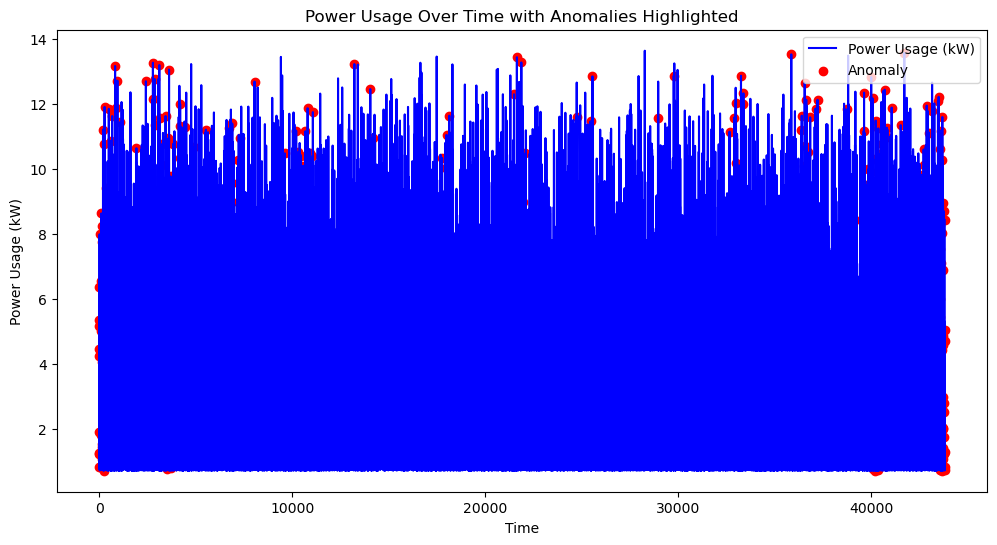

In [6]:
import matplotlib.pyplot as plt

# Plot power usage over time with anomalies highlighted
plt.figure(figsize=(12, 6))
plt.plot(data.index, data['Power Usage (kW)'], label='Power Usage (kW)', color='blue')
plt.scatter(data[data['Anomaly'] == -1].index, data[data['Anomaly'] == -1]['Power Usage (kW)'], 
            color='red', label='Anomaly')
plt.title('Power Usage Over Time with Anomalies Highlighted')
plt.xlabel('Time')
plt.ylabel('Power Usage (kW)')
plt.legend()
plt.show()

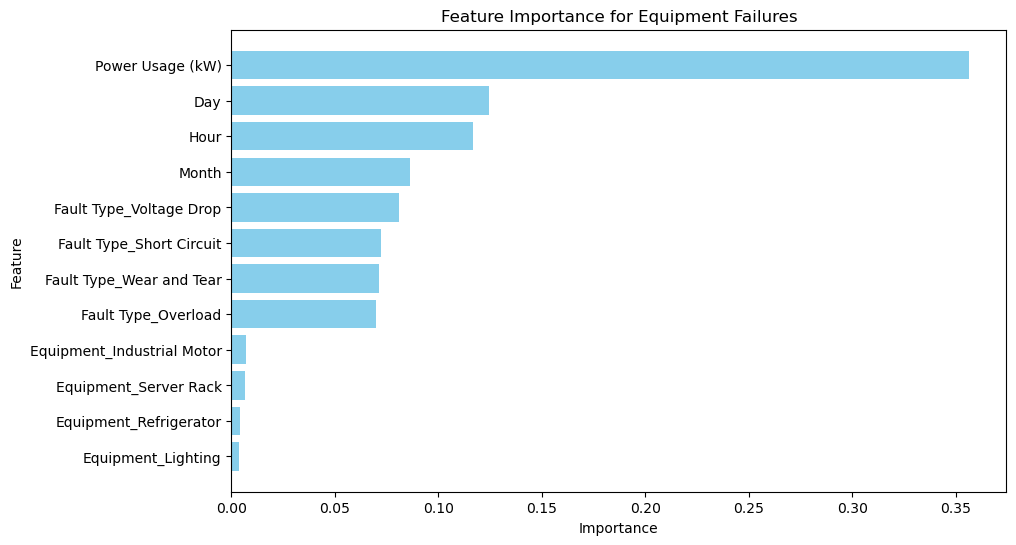

In [7]:
# Get feature importances from the Random Forest model
importances = random_forest.feature_importances_
feature_names = X.columns

# Create a DataFrame for visualization
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Plot feature importances
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='skyblue')
plt.title('Feature Importance for Equipment Failures')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.gca().invert_yaxis()  # Show the most important feature at the top
plt.show()

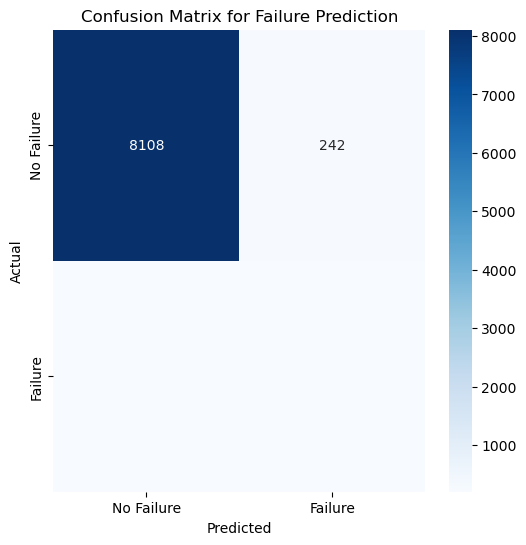

In [8]:
import seaborn as sns

# Generate confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Plot confusion matrix as a heatmap
plt.figure(figsize=(6, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Failure', 'Failure'], 
            yticklabels=['No Failure', 'Failure'])
plt.title('Confusion Matrix for Failure Prediction')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

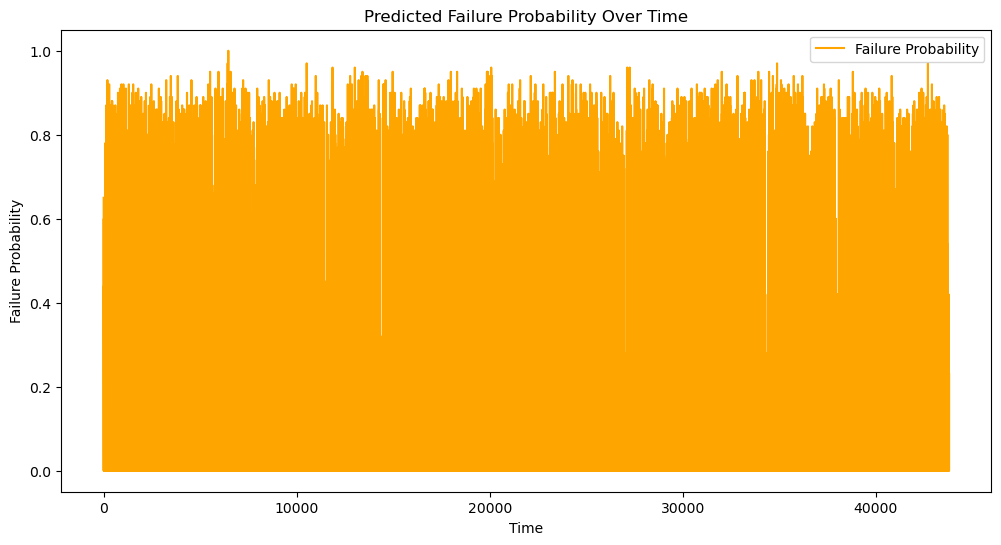

In [9]:
# Add predicted failure probability to the dataset
data['Predicted Failure Probability'] = random_forest.predict_proba(X)[:, 1]

# Plot failure probability over time
plt.figure(figsize=(12, 6))
plt.plot(data.index, data['Predicted Failure Probability'], label='Failure Probability', color='orange')
plt.title('Predicted Failure Probability Over Time')
plt.xlabel('Time')
plt.ylabel('Failure Probability')
plt.legend()
plt.show()